In [24]:
# imports

from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict , Annotated
from dotenv import load_dotenv
from pydantic import BaseModel, Field
from langgraph.checkpoint.memory import MemorySaver, InMemorySaver # ram
from langchain_core.messages import BaseMessage, HumanMessage
import operator
import os 


In [25]:
# loading 

load_dotenv()
GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")

In [26]:
# define llm


# llm 
llm = ChatGoogleGenerativeAI(
    model="gemini-3.1-flash-lite",
    temperature=0,
    google_api_key=GOOGLE_API_KEY
)


In [27]:
class jokeState(TypedDict):
    topic: str
    joke: str
    explanation: str
    

In [28]:
def generate_joke(state: jokeState):
    prompt = f"generate a joke on the topic {state['topic']}"
    response = llm.invoke(prompt).content
    return {
        'joke': response
    }

In [29]:
def generate_explanation(state: jokeState):
    prompt = f"write an explanation for the joke - {state['joke']}"
    response = llm.invoke(prompt).content
    return {
        'explanation': response
    }

In [30]:

graph = StateGraph(jokeState)

graph.add_node('generate_joke',generate_joke)
graph.add_node('generate_explanation',generate_explanation)



graph.add_edge(START,'generate_joke')
graph.add_edge('generate_joke','generate_explanation')
graph.add_edge('generate_explanation',END)


checkpointer = InMemorySaver()
workflow = graph.compile(checkpointer=checkpointer)

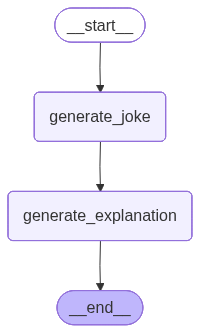

In [31]:
workflow

In [32]:
config1 = {
    'configurable': {
        'thread_id':'1'
    }
}

workflow.invoke({
    'topic': 'Football',
    
},config=config1)

{'topic': 'Football',
 'joke': [{'type': 'text',
   'text': 'Why are football players so good at math?\n\nBecause they know how to use their **cleats** to calculate the **angles**, but they still always get stuck when they have to **divide the points!**',
   'extras': {'signature': 'EjQKMgEMOdbH+WC9g4WavZmskz4TjwPAnOV2R6Z+kDMadyrOStkmt5a0cqtlCupGDTJq7Ff2'}}],
 'explanation': [{'type': 'text',
   'text': 'This joke relies on a play on words (puns) that connects the terminology of American football with mathematical concepts. Here is the breakdown:\n\n**1. "Cleats" vs. "Calculators"**\n*   **The Pun:** The joke uses the word **"cleats"** (the spiked shoes football players wear for traction) as a play on the word **"calculate."** \n*   **The Meaning:** In math, you use a calculator to solve problems. In football, players use their "cleats" to navigate the field. The joke suggests that because they are constantly adjusting their footing to make sharp turns, they are essentially "calculatin

In [33]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'Football', 'joke': [{'type': 'text', 'text': 'Why are football players so good at math?\n\nBecause they know how to use their **cleats** to calculate the **angles**, but they still always get stuck when they have to **divide the points!**', 'extras': {'signature': 'EjQKMgEMOdbH+WC9g4WavZmskz4TjwPAnOV2R6Z+kDMadyrOStkmt5a0cqtlCupGDTJq7Ff2'}}], 'explanation': [{'type': 'text', 'text': 'This joke relies on a play on words (puns) that connects the terminology of American football with mathematical concepts. Here is the breakdown:\n\n**1. "Cleats" vs. "Calculators"**\n*   **The Pun:** The joke uses the word **"cleats"** (the spiked shoes football players wear for traction) as a play on the word **"calculate."** \n*   **The Meaning:** In math, you use a calculator to solve problems. In football, players use their "cleats" to navigate the field. The joke suggests that because they are constantly adjusting their footing to make sharp turns, they are essentially "

In [34]:
list(workflow.get_state_history(config1)) # all of the intermediate state

[StateSnapshot(values={'topic': 'Football', 'joke': [{'type': 'text', 'text': 'Why are football players so good at math?\n\nBecause they know how to use their **cleats** to calculate the **angles**, but they still always get stuck when they have to **divide the points!**', 'extras': {'signature': 'EjQKMgEMOdbH+WC9g4WavZmskz4TjwPAnOV2R6Z+kDMadyrOStkmt5a0cqtlCupGDTJq7Ff2'}}], 'explanation': [{'type': 'text', 'text': 'This joke relies on a play on words (puns) that connects the terminology of American football with mathematical concepts. Here is the breakdown:\n\n**1. "Cleats" vs. "Calculators"**\n*   **The Pun:** The joke uses the word **"cleats"** (the spiked shoes football players wear for traction) as a play on the word **"calculate."** \n*   **The Meaning:** In math, you use a calculator to solve problems. In football, players use their "cleats" to navigate the field. The joke suggests that because they are constantly adjusting their footing to make sharp turns, they are essentially 

In [35]:
config2 = {
    'configurable': {
        'thread_id':'2'
    }
}


workflow.invoke({
    'topic': 'cricket',
    
},config=config2)

{'topic': 'cricket',
 'joke': [{'type': 'text',
   'text': 'Why is it so hard to play cricket in the jungle?\n\nBecause there are too many **cheetahs**!',
   'extras': {'signature': 'EjQKMgEMOdbHo9dRsvctVA5BFjFuVfksZG3hSQz6DgWUUQxYjYTr4q4zq+5aXX+LMAakbm9a'}}],
 'explanation': [{'type': 'text',
   'text': 'This joke relies on a **pun** (a play on words) involving two similar-sounding terms:\n\n1.  **Cheetahs:** A type of wild cat known for being very fast.\n2.  **Cheaters:** People who act dishonestly or break the rules of a game.\n\n**The explanation:**\nIn the sport of cricket, as in any game, "cheating" is against the rules. The joke creates a humorous scenario where you cannot play cricket in the jungle because the animals are "cheetahs" (the animal). Because the word "cheetahs" sounds exactly like "cheaters," the joke implies that the game would be impossible to play fairly because everyone would be breaking the rules.',
   'extras': {'signature': 'EjQKMgEMOdbHguZm+2H3AC8T/r1IwVHdI

In [36]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'Football', 'joke': [{'type': 'text', 'text': 'Why are football players so good at math?\n\nBecause they know how to use their **cleats** to calculate the **angles**, but they still always get stuck when they have to **divide the points!**', 'extras': {'signature': 'EjQKMgEMOdbH+WC9g4WavZmskz4TjwPAnOV2R6Z+kDMadyrOStkmt5a0cqtlCupGDTJq7Ff2'}}], 'explanation': [{'type': 'text', 'text': 'This joke relies on a play on words (puns) that connects the terminology of American football with mathematical concepts. Here is the breakdown:\n\n**1. "Cleats" vs. "Calculators"**\n*   **The Pun:** The joke uses the word **"cleats"** (the spiked shoes football players wear for traction) as a play on the word **"calculate."** \n*   **The Meaning:** In math, you use a calculator to solve problems. In football, players use their "cleats" to navigate the field. The joke suggests that because they are constantly adjusting their footing to make sharp turns, they are essentially "

In [37]:
list(workflow.get_state_history(config1)) # all of the intermediate state

[StateSnapshot(values={'topic': 'Football', 'joke': [{'type': 'text', 'text': 'Why are football players so good at math?\n\nBecause they know how to use their **cleats** to calculate the **angles**, but they still always get stuck when they have to **divide the points!**', 'extras': {'signature': 'EjQKMgEMOdbH+WC9g4WavZmskz4TjwPAnOV2R6Z+kDMadyrOStkmt5a0cqtlCupGDTJq7Ff2'}}], 'explanation': [{'type': 'text', 'text': 'This joke relies on a play on words (puns) that connects the terminology of American football with mathematical concepts. Here is the breakdown:\n\n**1. "Cleats" vs. "Calculators"**\n*   **The Pun:** The joke uses the word **"cleats"** (the spiked shoes football players wear for traction) as a play on the word **"calculate."** \n*   **The Meaning:** In math, you use a calculator to solve problems. In football, players use their "cleats" to navigate the field. The joke suggests that because they are constantly adjusting their footing to make sharp turns, they are essentially 

In [38]:
workflow.get_state(config2)

StateSnapshot(values={'topic': 'cricket', 'joke': [{'type': 'text', 'text': 'Why is it so hard to play cricket in the jungle?\n\nBecause there are too many **cheetahs**!', 'extras': {'signature': 'EjQKMgEMOdbHo9dRsvctVA5BFjFuVfksZG3hSQz6DgWUUQxYjYTr4q4zq+5aXX+LMAakbm9a'}}], 'explanation': [{'type': 'text', 'text': 'This joke relies on a **pun** (a play on words) involving two similar-sounding terms:\n\n1.  **Cheetahs:** A type of wild cat known for being very fast.\n2.  **Cheaters:** People who act dishonestly or break the rules of a game.\n\n**The explanation:**\nIn the sport of cricket, as in any game, "cheating" is against the rules. The joke creates a humorous scenario where you cannot play cricket in the jungle because the animals are "cheetahs" (the animal). Because the word "cheetahs" sounds exactly like "cheaters," the joke implies that the game would be impossible to play fairly because everyone would be breaking the rules.', 'extras': {'signature': 'EjQKMgEMOdbHguZm+2H3AC8T/r

In [39]:
list(workflow.get_state_history(config2)) # all of the intermediate state

[StateSnapshot(values={'topic': 'cricket', 'joke': [{'type': 'text', 'text': 'Why is it so hard to play cricket in the jungle?\n\nBecause there are too many **cheetahs**!', 'extras': {'signature': 'EjQKMgEMOdbHo9dRsvctVA5BFjFuVfksZG3hSQz6DgWUUQxYjYTr4q4zq+5aXX+LMAakbm9a'}}], 'explanation': [{'type': 'text', 'text': 'This joke relies on a **pun** (a play on words) involving two similar-sounding terms:\n\n1.  **Cheetahs:** A type of wild cat known for being very fast.\n2.  **Cheaters:** People who act dishonestly or break the rules of a game.\n\n**The explanation:**\nIn the sport of cricket, as in any game, "cheating" is against the rules. The joke creates a humorous scenario where you cannot play cricket in the jungle because the animals are "cheetahs" (the animal). Because the word "cheetahs" sounds exactly like "cheaters," the joke implies that the game would be impossible to play fairly because everyone would be breaking the rules.', 'extras': {'signature': 'EjQKMgEMOdbHguZm+2H3AC8T/

In [ ]:
# benifit of persistence
# 1. shorterm memory
# 2. falt tolerence
# 3. HITL
# 4. Time travel


Time Travel

In [41]:
workflow.get_state({
    "configurable": 
    {"thread_id": "2",
     
    "checkpoint_id": "1f16e387-a0a0-60e5-8001-46991a30db2f"}})

StateSnapshot(values={'topic': 'cricket', 'joke': [{'type': 'text', 'text': 'Why is it so hard to play cricket in the jungle?\n\nBecause there are too many **cheetahs**!', 'extras': {'signature': 'EjQKMgEMOdbHo9dRsvctVA5BFjFuVfksZG3hSQz6DgWUUQxYjYTr4q4zq+5aXX+LMAakbm9a'}}]}, next=('generate_explanation',), config={'configurable': {'thread_id': '2', 'checkpoint_id': '1f16e387-a0a0-60e5-8001-46991a30db2f'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-06-22T12:47:06.989590+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f16e387-99ef-6fc2-8000-9bd78e35ae7f'}}, tasks=(PregelTask(id='3268b538-2874-298d-2fda-0f7beb2f4d3e', name='generate_explanation', path=('__pregel_pull', 'generate_explanation'), error=None, interrupts=(), state=None, result={'explanation': [{'type': 'text', 'text': 'This joke relies on a **pun** (a play on words) involving two similar-sounding terms:\n\n1.  **Cheetahs:** A type of wild cat known

In [42]:
workflow.invoke(None, {
    "configurable":
     {"thread_id": "2",
      "checkpoint_id": "1f16e387-a0a0-60e5-8001-46991a30db2f"}})

{'topic': 'cricket',
 'joke': [{'type': 'text',
   'text': 'Why is it so hard to play cricket in the jungle?\n\nBecause there are too many **cheetahs**!',
   'extras': {'signature': 'EjQKMgEMOdbHo9dRsvctVA5BFjFuVfksZG3hSQz6DgWUUQxYjYTr4q4zq+5aXX+LMAakbm9a'}}],
 'explanation': [{'type': 'text',
   'text': 'This joke relies on a **pun** (a play on words) involving two similar-sounding terms:\n\n1.  **Cheetahs:** A type of wild cat known for being very fast.\n2.  **Cheaters:** People who act dishonestly or break the rules of a game.\n\n**The explanation:**\nIn the sport of cricket, as in any game, "cheating" is against the rules. The joke creates a humorous scenario where you cannot play cricket in the jungle because the animals are "cheetahs" (the animal). Because the word "cheetahs" sounds exactly like "cheaters," the joke implies that the game would be impossible to play fairly because everyone would be breaking the rules.',
   'extras': {'signature': 'EjQKMgEMOdbHACQ6C6Cqy1vsr008SqBAV

In [43]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'cricket', 'joke': [{'type': 'text', 'text': 'Why is it so hard to play cricket in the jungle?\n\nBecause there are too many **cheetahs**!', 'extras': {'signature': 'EjQKMgEMOdbHo9dRsvctVA5BFjFuVfksZG3hSQz6DgWUUQxYjYTr4q4zq+5aXX+LMAakbm9a'}}], 'explanation': [{'type': 'text', 'text': 'This joke relies on a **pun** (a play on words) involving two similar-sounding terms:\n\n1.  **Cheetahs:** A type of wild cat known for being very fast.\n2.  **Cheaters:** People who act dishonestly or break the rules of a game.\n\n**The explanation:**\nIn the sport of cricket, as in any game, "cheating" is against the rules. The joke creates a humorous scenario where you cannot play cricket in the jungle because the animals are "cheetahs" (the animal). Because the word "cheetahs" sounds exactly like "cheaters," the joke implies that the game would be impossible to play fairly because everyone would be breaking the rules.', 'extras': {'signature': 'EjQKMgEMOdbHACQ6C6Cqy1vsr

Updating State

In [44]:
workflow.update_state({
    "configurable":
     {"thread_id": "2",
      "checkpoint_id": "1f16e387-a0a0-60e5-8001-46991a30db2f",
       "checkpoint_ns": ""}}, {'topic':'Tenis'})

{'configurable': {'thread_id': '2',
  'checkpoint_ns': '',
  'checkpoint_id': '1f16e3a5-4d6e-62e4-8002-6e1593da1512'}}

In [45]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'Tenis', 'joke': [{'type': 'text', 'text': 'Why is it so hard to play cricket in the jungle?\n\nBecause there are too many **cheetahs**!', 'extras': {'signature': 'EjQKMgEMOdbHo9dRsvctVA5BFjFuVfksZG3hSQz6DgWUUQxYjYTr4q4zq+5aXX+LMAakbm9a'}}]}, next=('generate_explanation',), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f16e3a5-4d6e-62e4-8002-6e1593da1512'}}, metadata={'source': 'update', 'step': 2, 'parents': {}}, created_at='2026-06-22T13:00:23.572349+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f16e387-a0a0-60e5-8001-46991a30db2f'}}, tasks=(PregelTask(id='0c597809-1750-19dc-d7e8-4f74a4605062', name='generate_explanation', path=('__pregel_pull', 'generate_explanation'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'cricket', 'joke': [{'type': 'text', 'text': 'Why is it so hard to play cricket in the jungle?\